In [56]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
import os

In [57]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 10

In [58]:
train_dir = '/Users/lakshmanmandapati/Downloads/Driver Distraction/StateFarm/train'
val_dir = '/Users/lakshmanmandapati/Downloads/Driver Distraction/StateFarm/val'

In [59]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)

In [60]:
val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 22424 images belonging to 10 classes.


In [61]:
val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 22424 images belonging to 10 classes.


In [62]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = '/Users/lakshmanmandapati/Downloads/Driver Distraction/StateFarm/train'

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Training set (80%)
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# Validation/Test set (20%)
val_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False  # important for evaluation
)


Found 17943 images belonging to 10 classes.
Found 4481 images belonging to 10 classes.


In [63]:
base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                         include_top=False,
                         weights='imagenet')

base_model.trainable = False

In [64]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [65]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [66]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [67]:
history = model.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=val_data
)

/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


2025-05-26 23:20:01.611843: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


701/701 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.1589 - loss: 2.3929

2025-05-26 23:22:42.372341: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


701/701 ━━━━━━━━━━━━━━━━━━━━ 238s 331ms/step - accuracy: 0.1589 - loss: 2.3926 - val_accuracy: 0.4873 - val_loss: 1.7436
Epoch 2/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 263s 374ms/step - accuracy: 0.3406 - loss: 1.8501 - val_accuracy: 0.6187 - val_loss: 1.3188
Epoch 3/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 282s 402ms/step - accuracy: 0.4497 - loss: 1.5698 - val_accuracy: 0.7124 - val_loss: 1.0735
Epoch 4/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 273s 390ms/step - accuracy: 0.5118 - loss: 1.4062 - val_accuracy: 0.7153 - val_loss: 0.9567
Epoch 5/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 279s 398ms/step - accuracy: 0.5531 - loss: 1.2794 - val_accuracy: 0.7637 - val_loss: 0.8455
Epoch 6/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 317s 452ms/step - accuracy: 0.5773 - loss: 1.2219 - val_accuracy: 0.7735 - val_loss: 0.8053
Epoch 7/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 284s 405ms/step - accuracy: 0.5989 - loss: 1.1682 - val_accuracy: 0.7722 - val_loss: 0.7646
Epoch 8/10
701/701 ━━━━━━━━━━━━━━━━━━━━ 280s 399ms/step - accuracy: 0.6229 - loss: 1.09

In [68]:
model.save('mobilenetv2_model_1.keras')

In [69]:
import os
print(os.getcwd())

/Users/lakshmanmandapati


In [70]:
model.save('/Users/lakshmanmandapati/Downloads/Driver Distraction/StateFarm/mobilenetv2_model.keras')

2025-05-27 00:06:26.522085: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


141/141 ━━━━━━━━━━━━━━━━━━━━ 24s 153ms/step
              precision    recall  f1-score   support

          c0       0.76      0.78      0.77       497
          c1       0.68      0.94      0.79       453
          c2       0.80      0.82      0.81       463
          c3       0.79      0.96      0.87       469
          c4       0.78      0.88      0.83       465
          c5       0.92      0.92      0.92       462
          c6       0.85      0.69      0.76       465
          c7       0.79      0.95      0.86       400
          c8       0.82      0.45      0.58       382
          c9       0.91      0.55      0.68       425

    accuracy                           0.80      4481
   macro avg       0.81      0.79      0.79      4481
weighted avg       0.81      0.80      0.79      4481



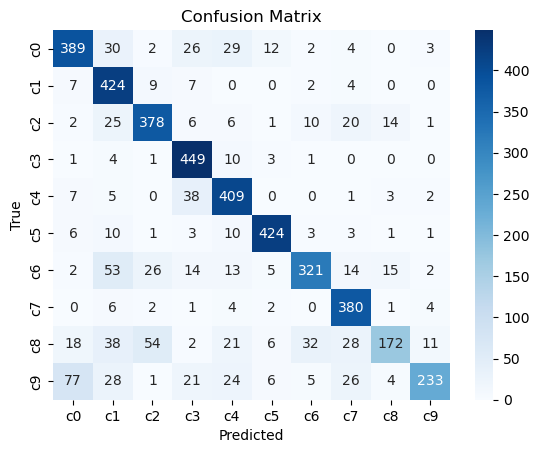

In [71]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predict on validation data
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)

# Get true labels
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# Print metrics
print(classification_report(y_true, y_pred, target_names=class_labels))

# Optional: confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


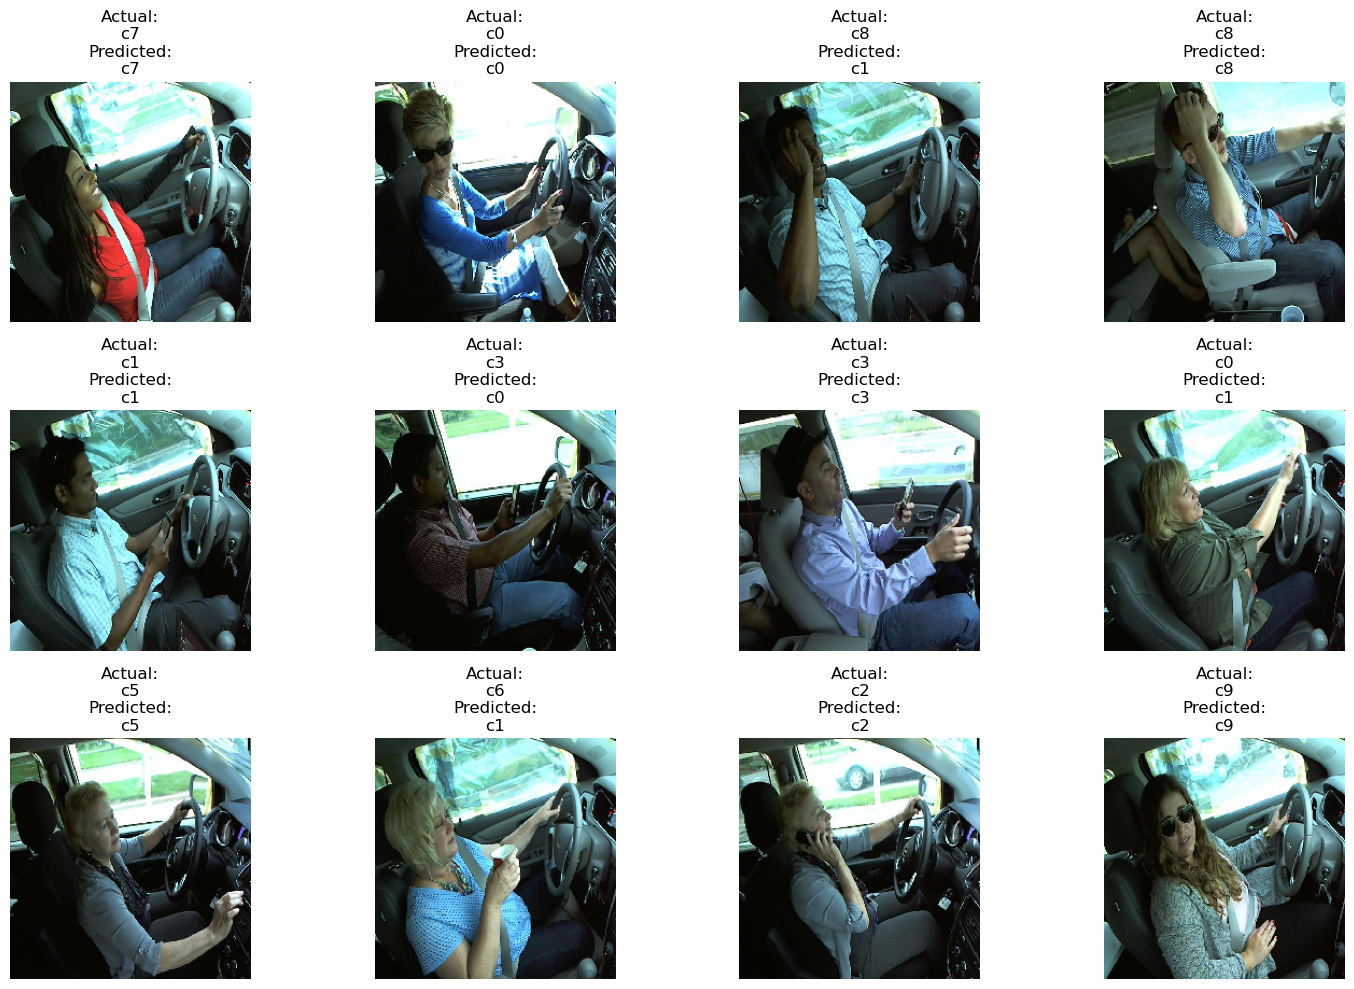

In [73]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os
import random

# Path to your training directory
train_dir = '/Users/lakshmanmandapati/Downloads/Driver Distraction/StateFarm/train'

# Get class labels (directories only)
class_labels = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

# Load your trained MobileNetV2 model
model = tf.keras.models.load_model('mobilenetv2_model_1.keras')

# Number of images to display
num_images = 12

# Prepare a list to hold image paths and their actual class labels
sample_images = []

for _ in range(num_images):
    # Pick a random class folder
    sample_class = random.choice(class_labels)
    sample_class_dir = os.path.join(train_dir, sample_class)

    # Get list of images inside that class folder (filter for images)
    images_in_class = [f for f in os.listdir(sample_class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Pick a random image from the class folder
    sample_image_name = random.choice(images_in_class)
    sample_image_path = os.path.join(sample_class_dir, sample_image_name)
    sample_images.append((sample_image_path, sample_class))  # store path & actual class

# Plotting
plt.figure(figsize=(15, 10))

for i, (img_path, actual_class) in enumerate(sample_images):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    preds = model.predict(img_array)
    predicted_class_index = np.argmax(preds[0])
    predicted_class_label = class_labels[predicted_class_index]

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Actual:\n{actual_class}\nPredicted:\n{predicted_class_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()
